In [41]:
!pip install splusdata --upgrade --quiet

In [2]:
import splusdata

In [3]:
bands = ["j0378", "j0395", "j0410", "j0430", "j0515", "j0660", "j0861", "g", "r", "i", "z", "u"]

In [4]:
conn = splusdata.Core()

In [5]:
tab = conn.query("""
select top 100 * from idr6.idr6           
""")

In [6]:
list(tab.columns)

['id',
 'random_idx',
 'ra',
 'dec',
 'field',
 'a_pixel_det',
 'a_restricted_pixel_r',
 'b_pixel_det',
 'b_restricted_pixel_r',
 'class_star_det',
 'class_star_g',
 'class_star_i',
 'class_star_j0378',
 'class_star_j0395',
 'class_star_j0410',
 'class_star_j0430',
 'class_star_j0515',
 'class_star_j0660',
 'class_star_j0861',
 'class_star_r',
 'class_star_u',
 'class_star_z',
 'ellipticity_det',
 'elongation_det',
 'err_a_pixel_det',
 'err_b_pixel_det',
 'err_mag_aper_3_g',
 'err_mag_aper_3_i',
 'err_mag_aper_3_j0378',
 'err_mag_aper_3_j0395',
 'err_mag_aper_3_j0410',
 'err_mag_aper_3_j0430',
 'err_mag_aper_3_j0515',
 'err_mag_aper_3_j0660',
 'err_mag_aper_3_j0861',
 'err_mag_aper_3_r',
 'err_mag_aper_3_u',
 'err_mag_aper_3_z',
 'err_mag_aper_6_g',
 'err_mag_aper_6_i',
 'err_mag_aper_6_j0378',
 'err_mag_aper_6_j0395',
 'err_mag_aper_6_j0410',
 'err_mag_aper_6_j0430',
 'err_mag_aper_6_j0515',
 'err_mag_aper_6_j0660',
 'err_mag_aper_6_j0861',
 'err_mag_aper_6_r',
 'err_mag_aper_6_u',
 '

In [ ]:
ra = 3.9925
dec = -0.3036

In [43]:
hdus = conn.stamp(ra, dec, 500, "R")

In [44]:
hdus[1].header

SIMPLE  =                    T                                                  
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  500                                                  
NAXIS2  =                  500                                                  
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
EQUINOX =        2000.00000000 / Mean equinox                                   
MJD-OBS =   5.766000000000E+04 / Modified Julian date at start                  
RADESYS = 'ICRS    '           / Astrometric system                             
CTYPE1  = 'RA---TAN'           / WCS projection type for this axis              
CUNIT1  = 'deg     '           / Axis unit                                      
CRVAL1  =   4.251968333330E+

In [45]:
import matplotlib.pyplot as plt
import numpy as np

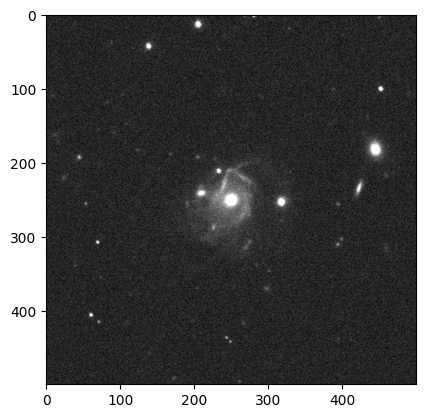

In [46]:
vmin, vmax = np.percentile(hdus[1].data, [0.1, 99.8])

plt.imshow(hdus[1].data, cmap="gray", vmin=vmin, vmax=vmax)
plt.show()

In [58]:
tab = conn.query(f"""
select id,ra,dec, a_pixel_det, b_pixel_det, mag_psf_r, theta_det
from idr6.idr6 
where cone(ra,dec,{ra}, {dec},0.5) 
and mag_psf_r < 22 and err_mag_psf_r < 0.3
""")

In [59]:
tab

,id,ra,dec,a_pixel_det,b_pixel_det,mag_psf_r,theta_det
0,i06S82000700NQY,3.557133,-0.544131,0.941132,0.756901,21.923493,76.264940
1,i06S82000700NTP,3.561354,-0.543059,1.810110,1.699061,20.849611,88.299840
2,i06S82000700NS3,3.571444,-0.543339,1.148076,1.043435,21.570350,76.904100
3,i06S82000700NVL,3.574582,-0.541702,1.580082,1.209668,21.471274,83.864685
4,i06S82000700NTT,3.576241,-0.542329,1.952262,1.159830,21.822364,32.559067
...,...,...,...,...,...,...,...
7756,i06S82000800104,4.362380,0.028026,1.431631,1.034257,21.410569,-17.388075
7757,i06S820007013RU,4.358412,0.032360,1.522076,1.289026,21.207411,-54.665700
7758,i06S8200080016F,4.358450,0.032301,1.873887,1.097051,21.495850,83.505090
7759,i06S820008003XX,4.254059,0.120798,2.076529,1.878357,19.748763,-11.924727


In [60]:
# plot id ra dec over the image

from astropy.wcs import WCS

wcs = WCS(hdus[1].header)

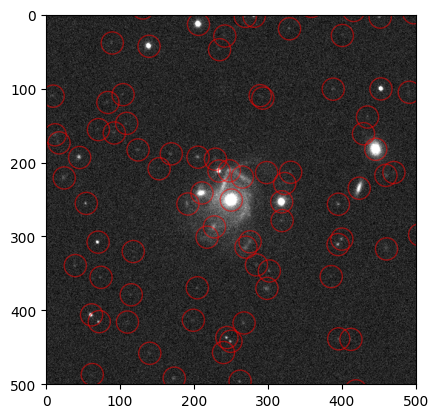

In [61]:
x, y = wcs.all_world2pix(tab['ra'], tab['dec'], 1)
plt.imshow(hdus[1].data, cmap="gray", vmin=vmin, vmax=vmax)
#plt.scatter(x, y, s=10, c='red', alpha=0.5)

# make circles around the sources
for i in range(len(x)):
    circle = plt.Circle((x[i], y[i] - 1), 15, color='red', fill=False, alpha=0.5)
    plt.gca().add_artist(circle)

# limit to the stamp size
plt.xlim(0, hdus[1].data.shape[1])
plt.ylim(hdus[1].data.shape[0], 0)

plt.show()

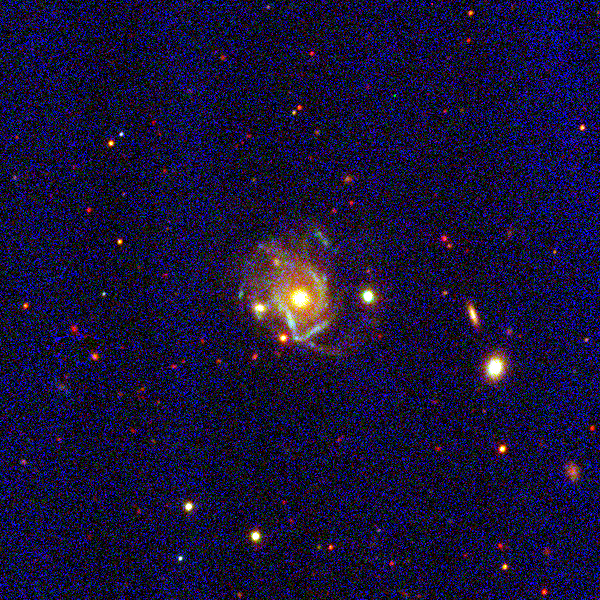

In [56]:
tri = conn.trilogy_image(
    ra=3.9925, dec=-0.3036, size=600,
    R=["R","I","F861","Z"], G=["G","F515","F660"], B=["U","F378","F395","F410","F430"],
    noiselum=0.15, satpercent=0.15, colorsatfac=2,
    data_release="dr4"
)
tri